<a href="https://colab.research.google.com/github/brigithsuarez-oss/CIENCIA-DE-DATOS-/blob/main/Tarea%201.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!pip install openmeteo-requests
!pip install requests-cache retry-requests numpy pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 229.1/229.1 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 849.3/849.3 kB 20.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.3/134.3 kB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 407.4/407.4 kB 26.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 52.6 MB/s eta 0:00:00
  Attempting uninstall: flatbuffers
    Found existing installation: flatbuffers 25.12.19
    Uninstalling flatbuffers-25.12.19:
      Successfully uninstalled flatbuffers-25.12.19
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.8/70.8 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.8/74.8 kB 6.7 MB/s eta 0:00:00


In [4]:
import openmeteo_requests

import pandas as pd
import requests_cache
from retry_requests import retry

# Setup the Open-Meteo API client with cache and retry on error
cache_session = requests_cache.CachedSession('.cache', expire_after = 3600)
retry_session = retry(cache_session, retries = 5, backoff_factor = 0.2)
openmeteo = openmeteo_requests.Client(session = retry_session)

# Make sure all required weather variables are listed here
# The order of variables in hourly or daily is important to assign them correctly below
url = "https://api.open-meteo.com/v1/forecast"
params = {
	"latitude": 52.52,
	"longitude": 13.41,
	"hourly": ["temperature_2m", "evapotranspiration", "rain", "precipitation_probability"],
}
responses = openmeteo.weather_api(url, params = params)

# Process first location. Add a for-loop for multiple locations or weather models
response = responses[0]
print(f"Coordinates: {response.Latitude()}°N {response.Longitude()}°E")
print(f"Elevation: {response.Elevation()} m asl")
print(f"Timezone difference to GMT+0: {response.UtcOffsetSeconds()}s")

# Process hourly data. The order of variables needs to be the same as requested.
hourly = response.Hourly()
hourly_temperature_2m = hourly.Variables(0).ValuesAsNumpy()
hourly_evapotranspiration = hourly.Variables(1).ValuesAsNumpy()
hourly_rain = hourly.Variables(2).ValuesAsNumpy()
hourly_precipitation_probability = hourly.Variables(3).ValuesAsNumpy()

hourly_data = {
	"date": pd.date_range(
		start = pd.to_datetime(hourly.Time(), unit = "s", utc = True),
		end =  pd.to_datetime(hourly.TimeEnd(), unit = "s", utc = True),
		freq = pd.Timedelta(seconds = hourly.Interval()),
		inclusive = "left"
	)
}

hourly_data["temperature_2m"] = hourly_temperature_2m
hourly_data["evapotranspiration"] = hourly_evapotranspiration
hourly_data["rain"] = hourly_rain
hourly_data["precipitation_probability"] = hourly_precipitation_probability

hourly_dataframe = pd.DataFrame(data = hourly_data)
print("\nHourly data\n", hourly_dataframe)

Coordinates: 52.52000045776367°N 13.419998168945312°E
Elevation: 38.0 m asl
Timezone difference to GMT+0: 0s

Hourly data
                          date  temperature_2m  evapotranspiration  rain  \
0   2026-09-23 00:00:00+00:00       10.345500                -0.0   0.0   
1   2026-09-23 01:00:00+00:00       10.095500                -0.0   0.0   
2   2026-09-23 02:00:00+00:00        9.695499                -0.0   0.0   
3   2026-09-23 03:00:00+00:00        9.145500                -0.0   0.0   
4   2026-09-23 04:00:00+00:00        8.645500                -0.0   0.0   
..                        ...             ...                 ...   ...   
163 2026-09-29 19:00:00+00:00       20.419500                 0.0   0.0   
164 2026-09-29 20:00:00+00:00       19.419500                 0.0   0.0   
165 2026-09-29 21:00:00+00:00       18.519501                 0.0   0.0   
166 2026-09-29 22:00:00+00:00       17.769501                 0.0   0.0   
167 2026-09-29 23:00:00+00:00       17.169500       

### Guardar los datos en un archivo local

Guardaremos el `hourly_dataframe` en un archivo CSV llamado `hourly_weather_data.csv`.

In [5]:
output_file_name = 'hourly_weather_data.csv'
hourly_dataframe.to_csv(output_file_name, index=False)
print(f"Datos guardados exitosamente en {output_file_name}")

Datos guardados exitosamente en hourly_weather_data.csv


### Realizar cinco gráficas de los datos con Matplotlib

Ahora, crearemos cinco visualizaciones diferentes del `hourly_dataframe` utilizando Matplotlib.

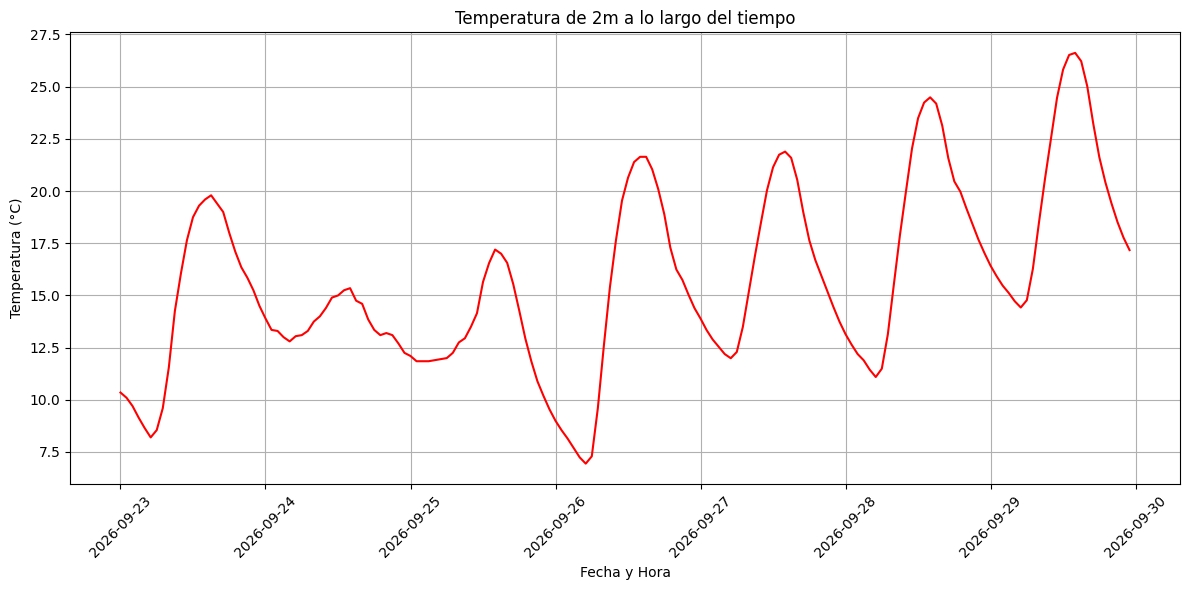

In [6]:
import matplotlib.pyplot as plt

# Gráfico 1: Temperatura de 2m a lo largo del tiempo
plt.figure(figsize=(12, 6))
plt.plot(hourly_dataframe['date'], hourly_dataframe['temperature_2m'], color='red')
plt.title('Temperatura de 2m a lo largo del tiempo')
plt.xlabel('Fecha y Hora')
plt.ylabel('Temperatura (°C)')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

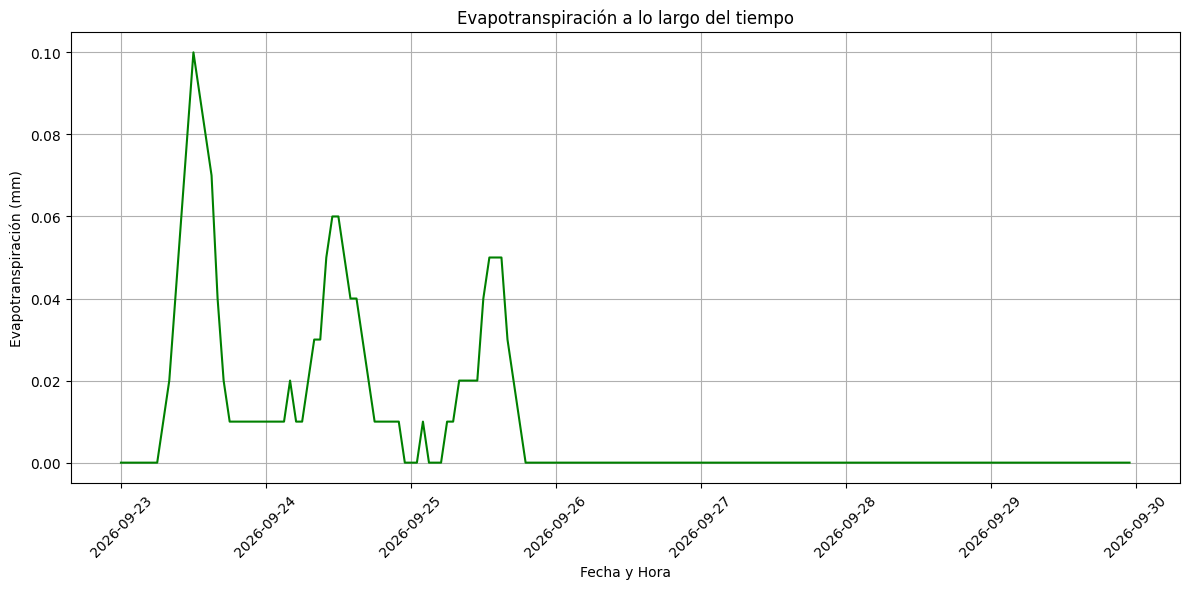

In [7]:
# Gráfico 2: Evapotranspiración a lo largo del tiempo
plt.figure(figsize=(12, 6))
plt.plot(hourly_dataframe['date'], hourly_dataframe['evapotranspiration'], color='green')
plt.title('Evapotranspiración a lo largo del tiempo')
plt.xlabel('Fecha y Hora')
plt.ylabel('Evapotranspiración (mm)')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

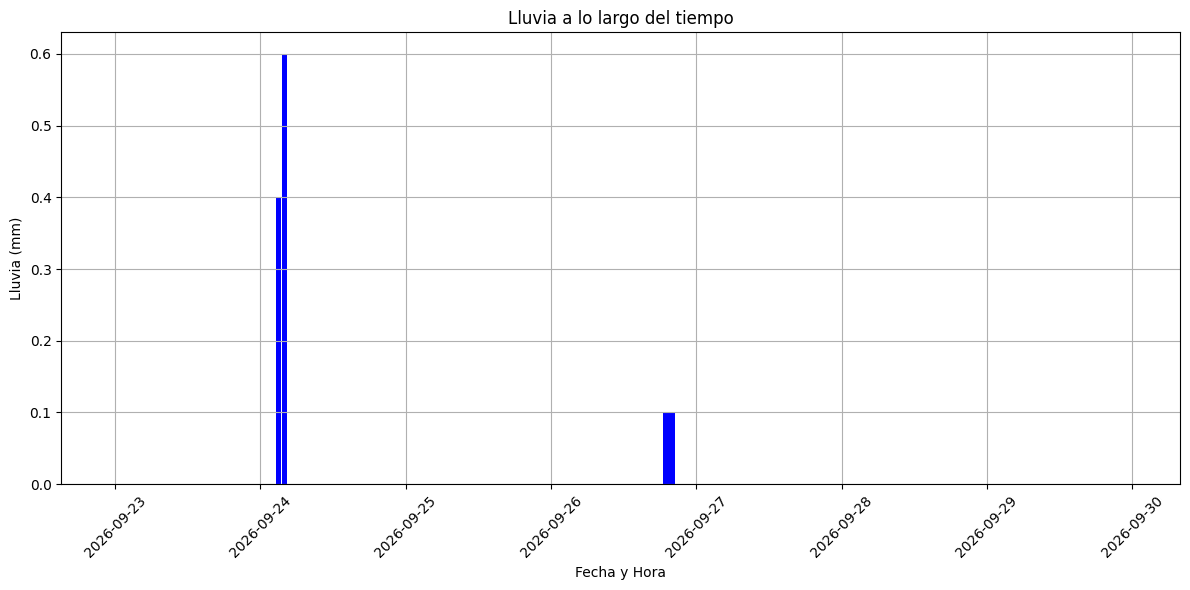

In [8]:
# Gráfico 3: Lluvia a lo largo del tiempo
plt.figure(figsize=(12, 6))
plt.bar(hourly_dataframe['date'], hourly_dataframe['rain'], color='blue', width=0.04)
plt.title('Lluvia a lo largo del tiempo')
plt.xlabel('Fecha y Hora')
plt.ylabel('Lluvia (mm)')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

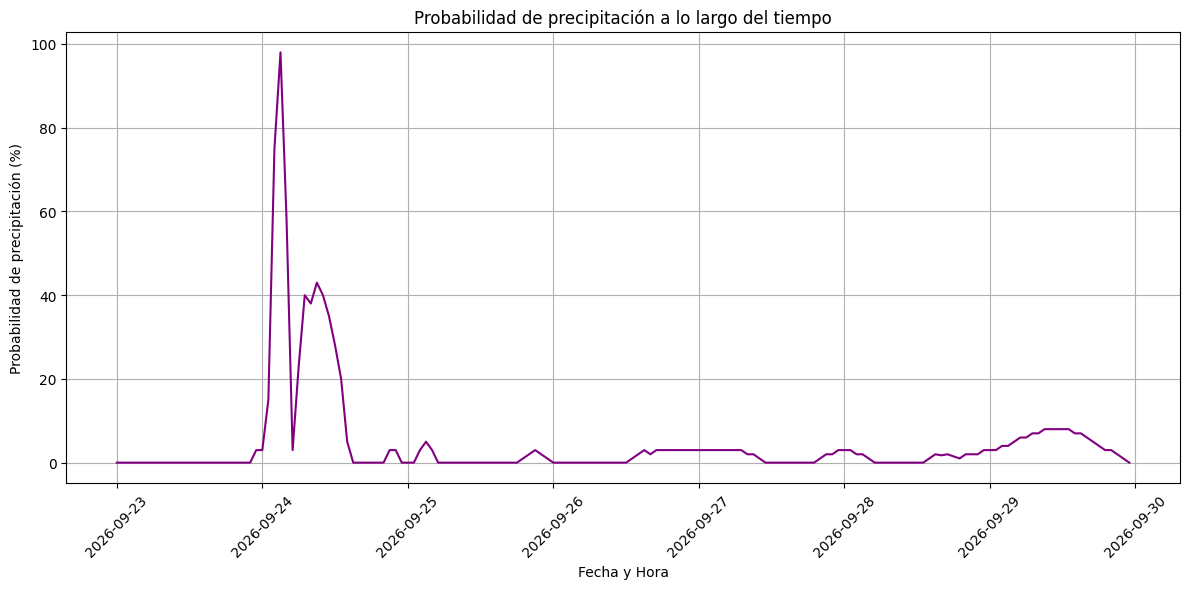

In [9]:
# Gráfico 4: Probabilidad de precipitación a lo largo del tiempo
plt.figure(figsize=(12, 6))
plt.plot(hourly_dataframe['date'], hourly_dataframe['precipitation_probability'], color='purple')
plt.title('Probabilidad de precipitación a lo largo del tiempo')
plt.xlabel('Fecha y Hora')
plt.ylabel('Probabilidad de precipitación (%)')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

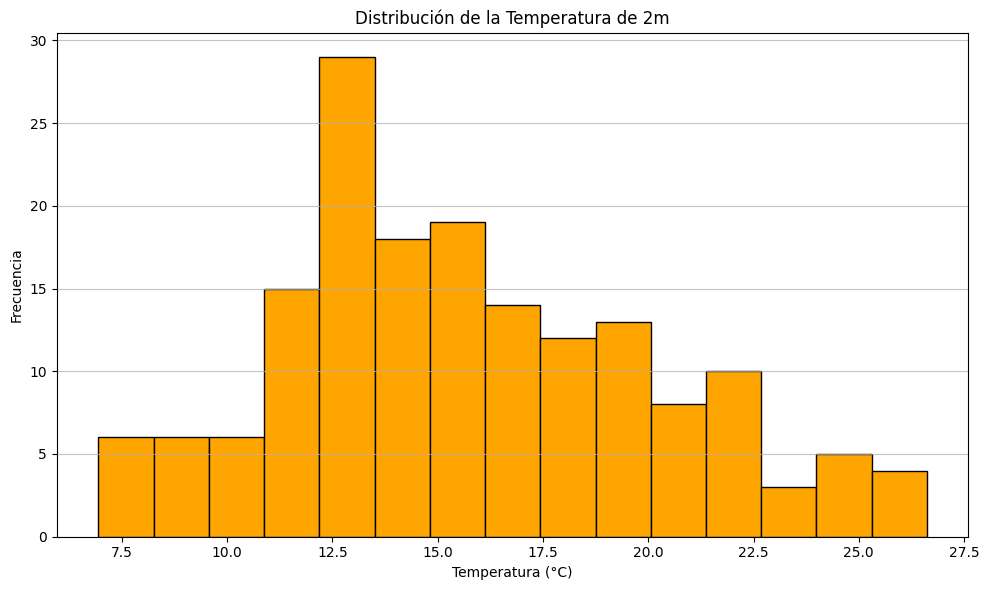

In [10]:
# Gráfico 5: Histograma de Temperatura de 2m
plt.figure(figsize=(10, 6))
plt.hist(hourly_dataframe['temperature_2m'], bins=15, color='orange', edgecolor='black')
plt.title('Distribución de la Temperatura de 2m')
plt.xlabel('Temperatura (°C)')
plt.ylabel('Frecuencia')
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()

### 1. Preparar el entorno para GitHub

Primero, instalaremos la herramienta `gh` (GitHub CLI) para facilitar la interacción con GitHub. Luego, necesitarás autenticarte.

In [11]:
# Instalar GitHub CLI
!apt-get install gh -y

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
gh is already the newest version (2.101.0).
0 upgraded, 0 newly installed, 0 to remove and 0 not upgraded.


### 2. Autenticar GitHub CLI

Ahora, necesitas autenticarte con GitHub. Ejecuta la siguiente celda y sigue las instrucciones en la consola. Esto te pedirá que abras un navegador para autorizar la aplicación de GitHub CLI.

**Importante:** Asegúrate de tener una cuenta de GitHub y de autorizar la aplicación cuando se te solicite en tu navegador.

In [14]:
# Autenticar gh CLI. Sigue las instrucciones interactivas en la salida.
!gh auth login

78? Where do you use GitHub?  [Use arrows to move, type to filter]
> GitHub.com
  Other
78? Where do you use GitHub? g  [Use arrows to move, type to filter]
> GitHub.com
78? Where do you use GitHub? gh  [Use arrows to move, type to filter]
78? Where do you use GitHub? gh   [Use arrows to move, type to filter]
78? Where do you use GitHub? gh r  [Use arrows to move, type to filter]
78? Where do you use GitHub? gh re  [Use arrows to move, type to filter]
78? Where do you use GitHub? gh rep  [Use arrows to move, type to filter]
78? Where do you use GitHub? gh repo  [Use arrows to move, type to filter]
78? Where do you use GitHub? gh repo   [Use arrows to move, type to filter]
78? Where do you use GitHub? gh repo c  [Use arrows to move, type to filter]
78? Where do you use GitHub? gh repo cl  [Use arrows to move, type to filter]
78? Where do you use GitHub? gh repo clo  [Use arrows to move, type to filter]
78? Where do you use GitHub? gh repo clon  [Use arrows to m

### 3. Clonar el repositorio y añadir los archivos

Una vez autenticado, clonaremos tu repositorio. Luego, copiaremos los archivos generados y tu notebook actual a la carpeta clonada.

**Nota Importante:** Después de ejecutar la siguiente celda para clonar, deberás guardar **este notebook actual** en la carpeta del repositorio que se creará (`CIENCIA-DE-DATOS-`). Puedes hacerlo desde `Archivo > Guardar una copia en GitHub` si ya has configurado Colab con GitHub, o descargando el archivo `.ipynb` y luego moviéndolo manualmente a la carpeta `CIENCIA-DE-DATOS-` en la interfaz de archivos de Colab (panel izquierdo).

In [16]:
# Clonar el repositorio
!gh repo clone brigithsuarez-oss/CIENCIA-DE-DATOS- ./CIENCIA-DE-DATOS-

# Cambiar al directorio del repositorio
%cd CIENCIA-DE-DATOS-

# Copiar el archivo CSV generado al repositorio
# Asegúrate de que 'hourly_weather_data.csv' exista en el directorio raíz de Colab
!cp ../hourly_weather_data.csv .

# Puedes crear un archivo README.md o modificar el existente
# Aquí crearemos uno simple si no existe
with open('README.md', 'w') as f:
    f.write("# CIENCIA-DE-DATOS-\n\nEste repositorio contiene el código y los datos generados de un análisis de datos meteorológicos.\n")

# Lista los archivos para verificar que estén en el directorio
!ls

To get started with GitHub CLI, please run:  gh auth login
Alternatively, populate the GH_TOKEN environment variable with a GitHub API authentication token.
[Errno 2] No such file or directory: 'CIENCIA-DE-DATOS-'
/content
cp: cannot stat '../hourly_weather_data.csv': No such file or directory
hourly_weather_data.csv  README.md  sample_data


### 4. Commitar y subir los cambios a GitHub

Finalmente, añadiremos todos los archivos, haremos un commit y los subiremos a tu repositorio.

In [17]:
# Añadir todos los cambios
!git add .

# Hacer un commit
!git commit -m "Añadir datos meteorológicos y notebook de análisis"

# Subir los cambios a GitHub
!git push origin main

fatal: not a git repository (or any of the parent directories): .git
fatal: not a git repository (or any of the parent directories): .git
fatal: not a git repository (or any of the parent directories): .git


Una vez que estos pasos se completen, tus archivos deberían estar en el repositorio de GitHub `brigithsuarez-oss/CIENCIA-DE-DATOS-`.